# BULC-D Early Detection — prototype monitoring notebook

**Default study area: Apostle Islands National Lakeshore, 2026 season.**

This notebook asks one question for each forested pixel in the study area: *compared with how it normally looks at this time of year, has it changed this season?* The answer is one of three outcomes:

| Outcome | Meaning |
|---|---|
| **Decrease / disturbance** | Vegetation signal dropped well below its normal range: harvest, blowdown, fire, insect or disease damage, flooding, clearing |
| **Unchanged** | Within its normal range |
| **Increase / growth** | Vegetation signal rose above its normal range: regrowth, recovery |

BULC-D detects *spectral* change. It does not say *what caused* it — that still needs local knowledge or a site visit.

**How to use it:** edit **Settings** (section 1) and run all cells. Apostle Islands loads a precomputed result by default. To try another area, set `USE_CUSTOM_AOI = True` and paste an Earth Engine FeatureCollection asset ID.


In [1]:
import dataclasses
import json
from pathlib import Path
from pprint import pprint

import ee
ee.Initialize(project="bulcd-python-rebuild")

from IPython.display import Markdown, display

from bulcd_early_detection import outputs, render
from bulcd_early_detection.config import MonitoringControls, build_config, config_summary

## 1. Settings

The only settings most runs need. Everything else is in **Advanced configuration** below.

In [2]:
# --- Study area ---------------------------------------------------------
# False: Apostle Islands National Lakeshore (precomputed result).
# True:  your own Earth Engine FeatureCollection (runs live; can be slow).
USE_CUSTOM_AOI = False
CUSTOM_AOI_ASSET = "projects/your-project/assets/your_feature_collection"

# --- Monitoring and baseline periods ----------------------------------------
controls = MonitoringControls(
    monitoring_year=2026,       # the season being checked for change
    season_start="06-01",       # MM-DD; the same window is used in every baseline year
    season_end="09-30",
    baseline_first_year=2018,   # "normal" is learned from these years (inclusive)
    baseline_last_year=2025,
    decision_threshold=0.5,     # map a change only where its probability exceeds this (0.5-0.99)
    sensitivity=1.0,            # >1 flags smaller departures from normal; 1.0 = standard
)

# Live runs over more than 1,000 km² are blocked unless this is True.
ALLOW_LARGE_AOI = False

## 2. Advanced configuration

The settings above are turned into a complete BULC-D configuration (`bulcd.config.schema.BULCDConfig`). Every BULC-D parameter is still available: edit it inside `advanced()` and the change applies to every run. It is printed in full after the study area loads (section 4).

Examples: switch off a sensor, change the transition matrix, or try the legacy levelers.

In [3]:
def advanced(config):
    """Edit any BULC-D config field here. Returns the config to run."""
    # config.evidence.target.sensors["S2"].enabled = False
    # config.bulc_advanced_params.posterior_leveler = 0.9
    # config.study_area.mask_non_forest = False
    return config


def build(controls, **aoi):
    return advanced(build_config(controls, **aoi))

## 3. Baseline configuration and known differences from the legacy GEE app

This notebook uses the configuration validated in Milestone 1 (`docs/findings.md`). It detected a 2026 fire 21 days after the event and a 2025 harvest 38 days after it started, both with >0.99 probability.

**What matches the legacy GEE app**
- **Transition matrix:** the legacy app's own hardcoded default (traced byte-for-byte to its source). This matrix and config reproduced a legacy GUI render with 97.9% class agreement.
- **Evidence:** NBR z-scores from a harmonic (constant + annual cycle) model of the baseline years, same season only.

**Known differences — not yet a full production match**
- **Levelers:** we use `dampening_factor=0.5` and `posterior_leveler=1.0` (off). The legacy app uses `initializingLeveler=0.7`, `transitionLeveler=0.7` and `posteriorLeveler=0.9`. The rebuild can't yet represent all three legacy levelers (BULC-D_rebuild decision 0004, "Open gap").
- **Baseline sensors:** Landsat 8 only. The Landsat 8 + Sentinel-2 multi-year baseline exceeded Earth Engine's memory limit. The monitoring season uses Landsat 8, Landsat 9 and Sentinel-2.
- **Masks:** water uses JRC Global Surface Water, and non-forest uses Hansen tree cover 2000. These are public substitutes for the legacy app's own masks. Non-forest land (beaches, open wetlands, developed areas) is **not analyzed** — BULC-D's normal-condition model is tuned for forest.
- **Mapping rule:** a change is mapped only where its final probability exceeds the decision threshold; everything else is "unchanged".
- **Park boundary:** from the World Database on Protected Areas (WDPA), not an official NPS boundary file.

**Things to keep in mind when reading the maps**
- Detection is not instant. Evidence builds up over several clear observations, about **3–6 weeks** after a change in our two Milestone 1 tests.
- Shoreline pixels mix land and water and can show scattered false changes, as can narrow linear features such as roads.

## 4. Study area

Checks the study area's size before anything runs. Apostle Islands uses a precomputed result; a custom area runs live, and each map below recomputes it.

In [4]:
PRECOMPUTED_FOLDER = "projects/bulcd-python-rebuild/assets/apostle_islands"
PRECOMPUTED_RUN = "apostle_2026_v1"

if USE_CUSTOM_AOI:
    area = outputs.from_asset(CUSTOM_AOI_ASSET)
    title_name = area.name
else:
    area = outputs.apostle_islands()
    title_name = "Apostle Islands National Lakeshore"

size = outputs.aoi_size_report(area)
w, s, e, n = size["bbox_degrees"]
print(f"Study area: {title_name}")
print(f"  area inside boundary: {size['area_km2']:,.0f} km²   (bounding box {size['bbox_km2']:,.0f} km²)")
print(f"  extent: {w:.3f}, {s:.3f} to {e:.3f}, {n:.3f}")

if USE_CUSTOM_AOI:
    if size["verdict"] == "ok":
        print("  size: within what has been run live before - expect a few minutes per map.")
    elif size["verdict"] == "slow":
        print(f"  WARNING: larger than anything run live so far (~{outputs.TESTED_LIVE_KM2} km²). "
              "Maps may take a long time or time out.")
    elif not ALLOW_LARGE_AOI:
        raise RuntimeError(
            f"Study area is {size['area_km2']:,.0f} km² (> {outputs.LARGE_AOI_KM2:,} km²). "
            "Use a smaller area, or set ALLOW_LARGE_AOI = True to try anyway."
        )
    else:
        print("  WARNING: very large study area - live maps will very likely time out.")

config = build(controls, **area.aoi)
display(Markdown("**Baseline settings for this run**\n\n| Setting | Value |\n|---|---|\n"
                 + "\n".join(f"| {k} | {v} |" for k, v in config_summary(config))))
print("Full BULC-D configuration for this run:")
pprint(dataclasses.asdict(config), width=110, compact=True)

Study area: Apostle Islands National Lakeshore
  area inside boundary: 277 km²   (bounding box 2,178 km²)
  extent: -91.053, 46.697 to -90.388, 47.084


**Baseline settings for this run**

| Setting | Value |
|---|---|
| Baseline (expectation) period | L8; years [(2018, 2025)]; DOY [(152, 273)] |
| Monitoring (target) period | L8, L9, S2; years [(2026, 2026)]; DOY [(152, 273)] |
| Spectral index | NBR |
| Expectation model | constant, unimodal |
| Sensitivity (z-score numerator factor) | 1.0 |
| Transition matrix | production (legacy default) |
| dampening_factor | 0.5 |
| posterior_leveler | 1.0 |
| initializing_leveler | 0.0 |
| recency_factor | 1.0 |
| Water mask / non-forest mask | True / True |

Full BULC-D configuration for this run:
{'bin_cuts': [-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2],
 'bulc_advanced_params': {'custom_transition_matrix': [[0.83, 0.08, 0.08], [0.66, 0.24, 0.08],
                                                       [0.53, 0.37, 0.08], [0.14, 0.76, 0.08],
                                                       [0.08, 0.83, 0.08], [0.08, 0.83, 0.08],
                                                       [0.08, 0.76, 0.14], [0.08, 0.37, 0.53],
                                                       [0.08, 0.24, 0.66], [0.08, 0.08, 0.83]],
                          'dampening_factor': 0.5,
                          'initializing_leveler': 0.0,
                          'posterior_leveler': 1.0,
                          'raw': {},
                          'recency_factor': 1.0},
 'evidence': {'day_step_size': 4,
              'expectation': {'sensors': {'L8': {'cloud_cover_threshold': 70,
                                                 'enabled': True,
       

## 5. Run BULC-D

Apostle Islands loads the precomputed result, after checking it was produced with the current settings. A custom area is computed live.

In [5]:
if USE_CUSTOM_AOI:
    results = outputs.outcome_image(config, controls.decision_threshold).clip(area.geometry)
    source = "live"
else:
    results, tile_meta = outputs.load_precomputed(PRECOMPUTED_FOLDER, PRECOMPUTED_RUN)
    expected = outputs.run_metadata(controls, config)
    matches = all(
        json.loads(m["controls_json"]) == json.loads(expected["controls_json"])
        and json.loads(m["config_json"]) == json.loads(expected["config_json"])
        for m in tile_meta
    )
    source = f"precomputed ({PRECOMPUTED_RUN})"
    if not matches:
        print("WARNING: settings differ from the precomputed Apostle Islands run - the maps below show the "
              "PRECOMPUTED settings. To use the new settings, run the export cell at the end of the notebook.")
print("Results source:", source)

frame = area.geometry.bounds(1).buffer(500, 100).bounds(1)   # map extent: study area + 500 m
ring = frame.coordinates().get(0).getInfo()
bbox = ring[0] + ring[2]   # [west, south, east, north] of the rendered frame
token = render.auth_token()
out_dir = Path("output") / f"{area.name}_{controls.monitoring_year}"
season = f"{controls.monitoring_start:%b %-d} – {controls.monitoring_end:%b %-d}, {controls.monitoring_year}"

Results source: precomputed (apostle_2026_v1)


## 6. Change this season

**The primary map.** Red: decrease/disturbance. Blue: increase/growth. Gray: unchanged. Lighter gray is land that wasn't analyzed (non-forest). Lake Superior and other water are shown pale blue and aren't analyzed.

*Changes are drawn slightly enlarged on this overview so small patches stay visible. The area table uses the exact 30 m pixels. Use **Zoom in** (section 8) to see real extents.*

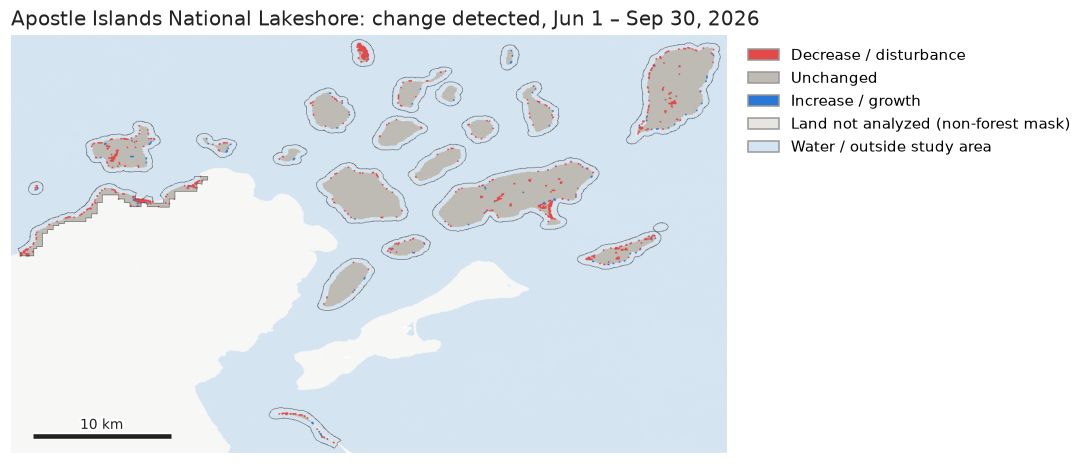

In [6]:
png = render.download_png(render.outcome_layer(results, area, frame, enlarge_changes=True), frame, token)
render.show_map(png, f"{title_name}: change detected, {season}", bbox,
                legend=render.outcome_legend(), save_to=out_dir / "outcome.png");

### Area by outcome

Land area only; water is excluded.

In [7]:
areas = outputs.area_summary(results, area.geometry)
analyzed = sum(v for k, v in areas.items() if "not analyzed" not in k)
rows = [f"| {k} | {v:,.2f} | {100 * v / analyzed:.1f}% |" if "not analyzed" not in k
        else f"| {k} | {v:,.2f} | — |" for k, v in areas.items()]
display(Markdown("| Outcome | Area (km²) | Share of analyzed land |\n|---|---:|---:|\n" + "\n".join(rows)))
(out_dir / "area_summary.json").write_text(json.dumps({"source": source, "km2": areas}, indent=2));

| Outcome | Area (km²) | Share of analyzed land |
|---|---:|---:|
| Decrease / disturbance | 2.34 | 1.4% |
| Unchanged | 161.73 | 98.4% |
| Increase / growth | 0.31 | 0.2% |
| Land not analyzed (non-forest mask) | 5.10 | — |

## 7. Supporting information

### How confident is each mapped change?
The final probability of each mapped change (darker means more certain). Only change pixels are colored. Unchanged land is almost uniformly near 1.0, so mapping it adds nothing. Change pixels are drawn enlarged, as on the main map.

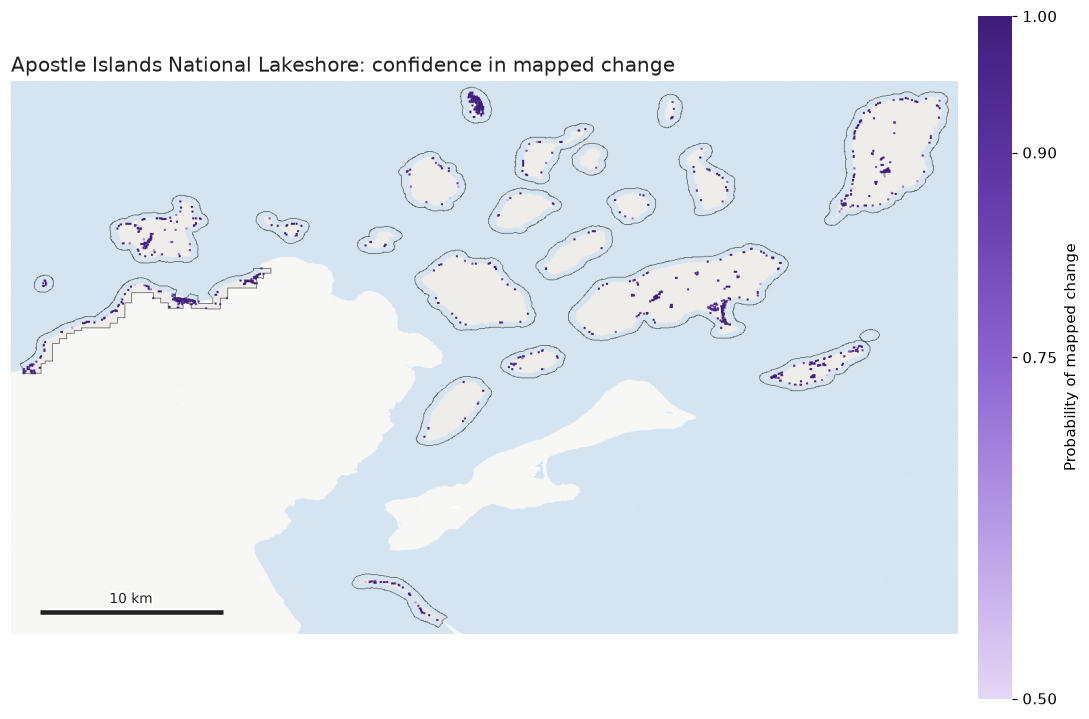

In [8]:
png = render.download_png(render.confidence_layer(results, area, frame, controls.decision_threshold, enlarge_changes=True), frame, token)
render.show_map(png, f"{title_name}: confidence in mapped change", bbox,
                colorbar=render.confidence_colorbar(controls.decision_threshold), save_to=out_dir / "confidence.png");

### When was each change first detected?
The first date a pixel's change probability passed the decision threshold (4-day resolution). Change pixels are drawn enlarged; unchanged land is pale.

How to read it: a change that *happens during* the season is typically detected a few weeks later. A change detected in the **first days of the season** was most likely already there when observations began — it happened before June, or the area differs from its baseline for some longer-running reason.

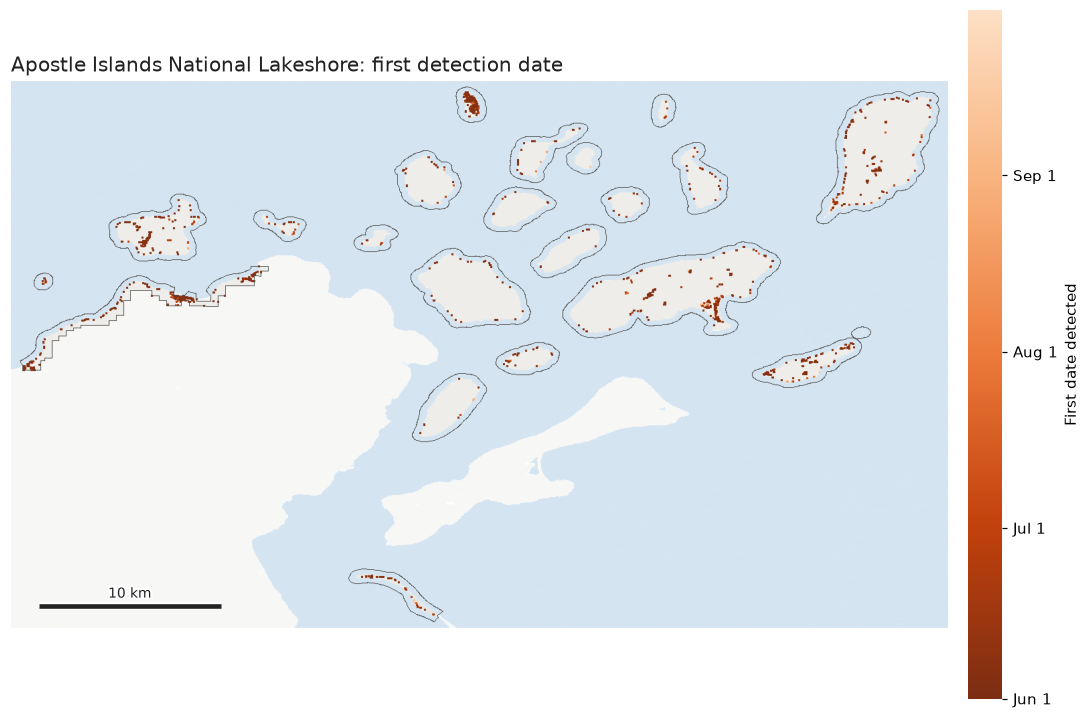

Mapped change: 2.64 km², of which 76% was first detected in the first two weeks of the season.


In [9]:
png = render.download_png(render.timing_layer(results, area, frame, controls.first_doy, controls.last_doy, enlarge_changes=True), frame, token)
render.show_map(png, f"{title_name}: first detection date", bbox,
                colorbar=render.timing_colorbar(controls.monitoring_year, controls.first_doy, controls.last_doy),
                save_to=out_dir / "first_detection.png")
timing = outputs.early_detection_share(results, area.geometry, controls.first_doy)
print(f"Mapped change: {timing['changed_km2']:.2f} km², of which {100 * timing['early_share']:.0f}% was first "
      f"detected in the first two weeks of the season.")

### Satellite imagery: before and after
Sentinel-2 false color (shortwave infrared / near infrared / red), independent of BULC-D, for context. Healthy forest is green, and bare or damaged ground is orange-brown. Water is dark. Both images cover the later half of the season: the last baseline year, then this year.

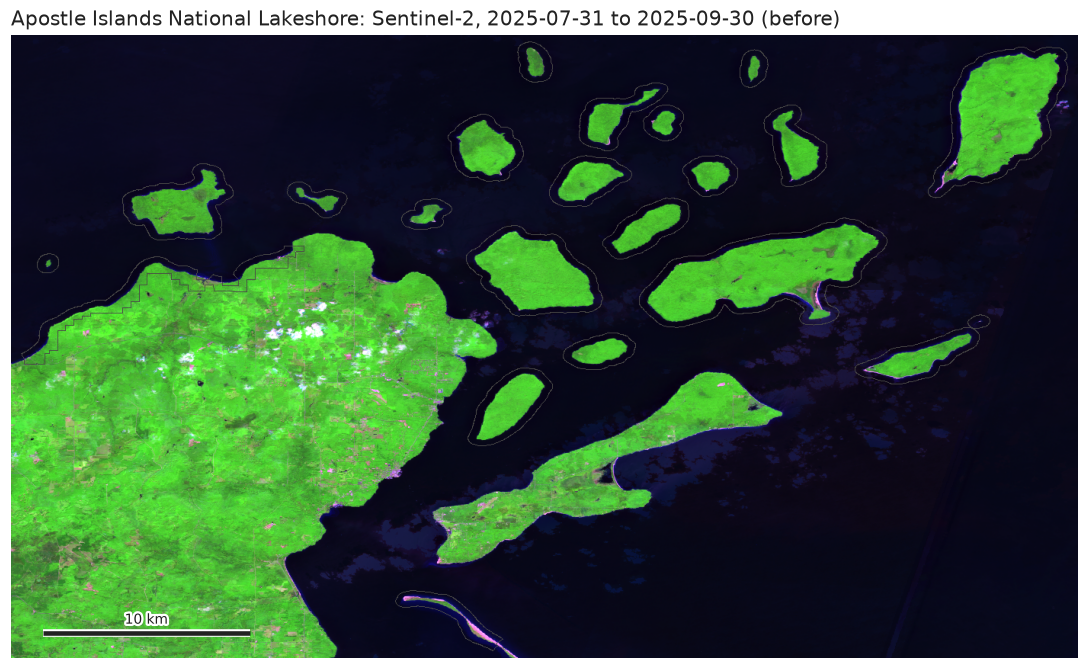

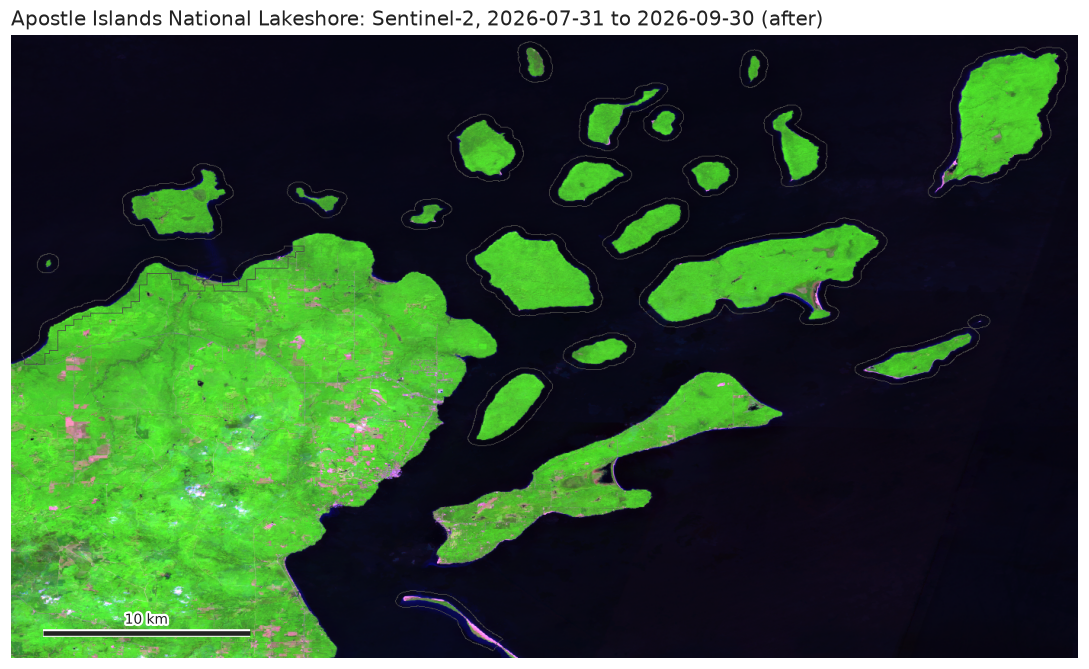

In [10]:
mid = controls.monitoring_start + (controls.monitoring_end - controls.monitoring_start) / 2
for year, label in [(controls.baseline_last_year, "before"), (controls.monitoring_year, "after")]:
    start, end = f"{year}-{mid:%m-%d}", f"{year}-{controls.season_end}"
    png = render.download_png(render.reference_layer(area, frame, start, end), frame, token)
    render.show_map(png, f"{title_name}: Sentinel-2, {start} to {end} ({label})", bbox,
                    save_to=out_dir / f"reference_{label}.png");

## 8. Zoom in

At full-park scale, a single 30 m change is about one screen pixel. Set a center point and a width to look closer. The default is the east end of Stockton Island.

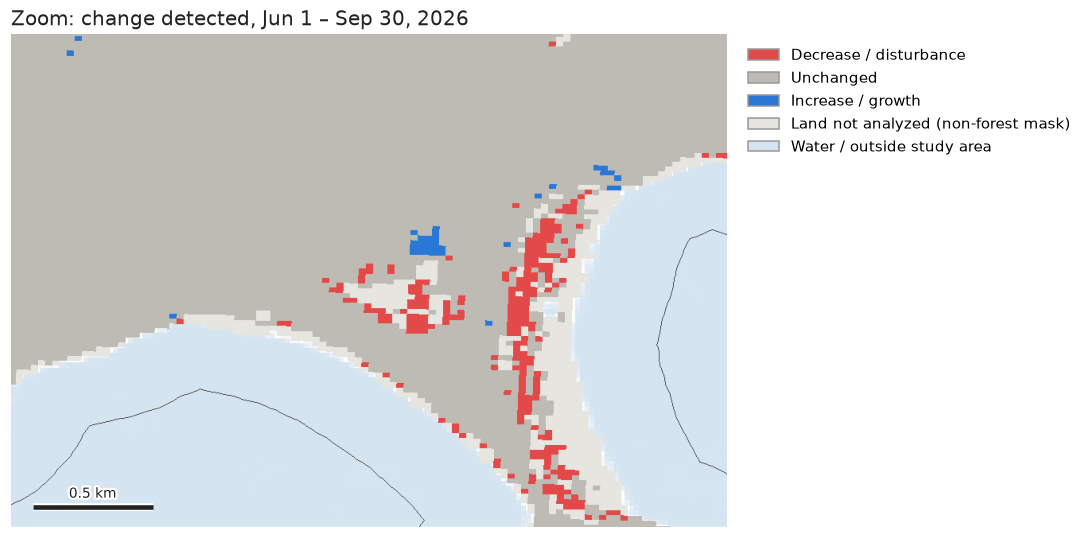

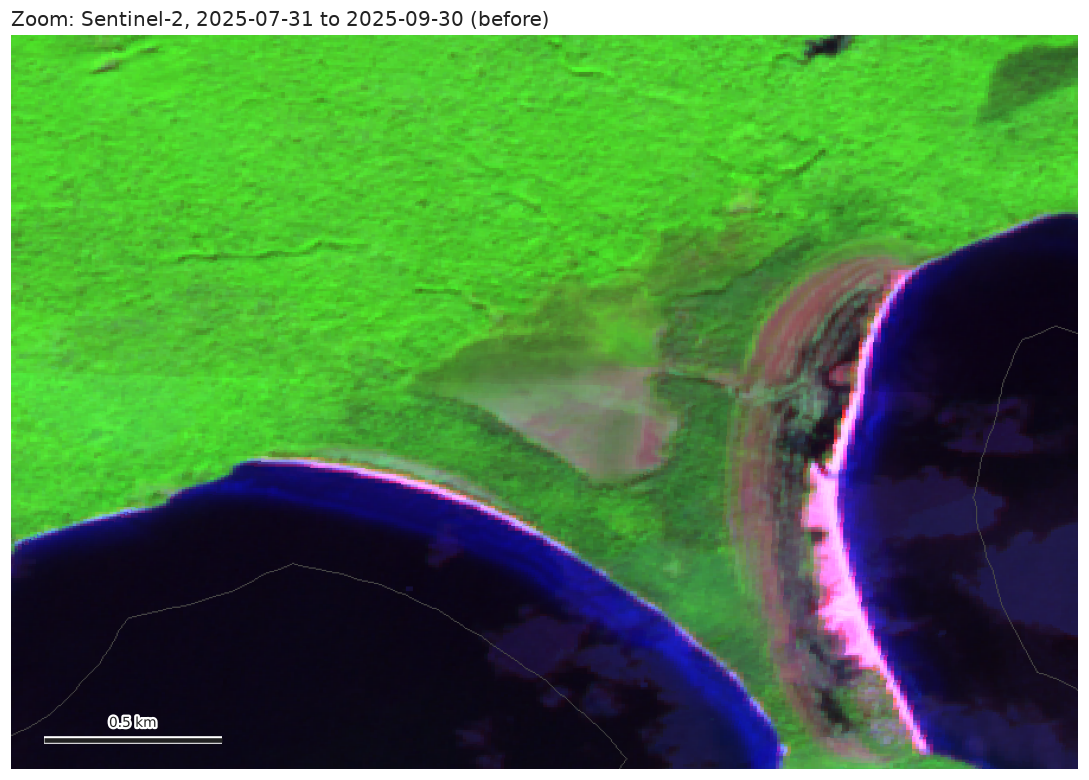

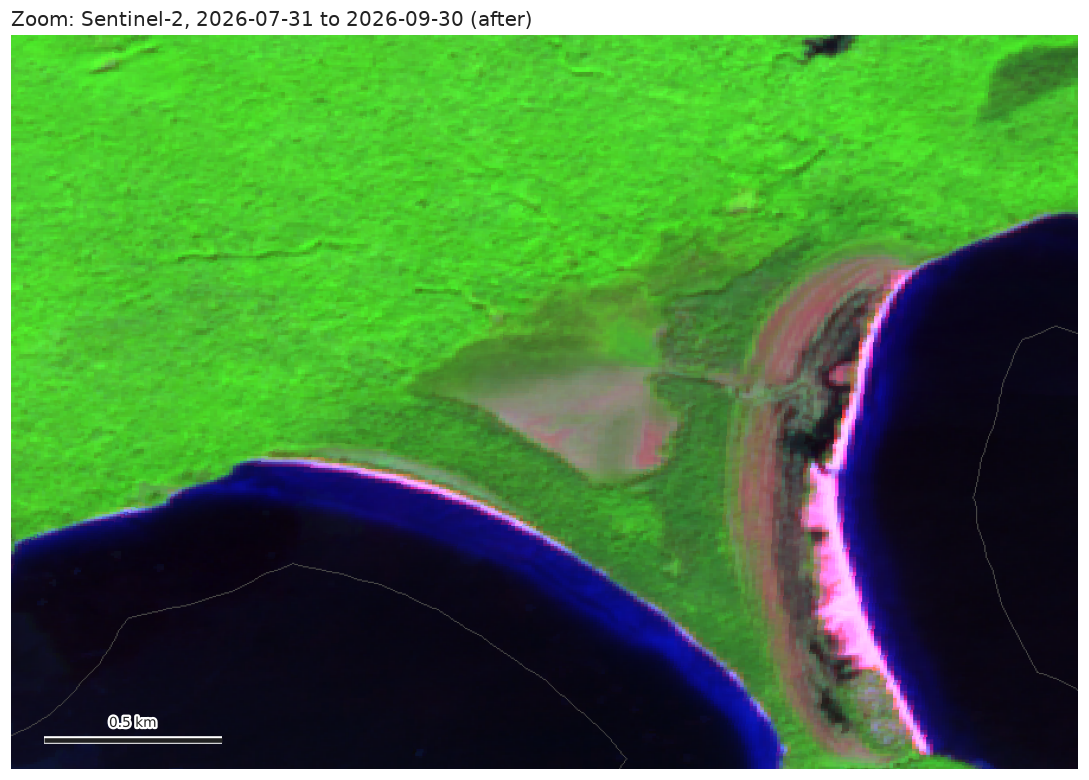

In [11]:
ZOOM_CENTER = (-90.558, 46.927)   # lon, lat
ZOOM_WIDTH_KM = 3

half = ZOOM_WIDTH_KM * 500
zoom = ee.Geometry.Point(ZOOM_CENTER).buffer(half).bounds(1)
ring = zoom.coordinates().get(0).getInfo()
zoom_bbox = ring[0] + ring[2]   # [west, south, east, north]
png = render.download_png(render.outcome_layer(results, area, zoom), zoom, token, 900)
render.show_map(png, f"Zoom: change detected, {season}", zoom_bbox, legend=render.outcome_legend(),
                save_to=out_dir / "zoom_outcome.png")
for year, label in [(controls.baseline_last_year, "before"), (controls.monitoring_year, "after")]:
    start, end = f"{year}-{mid:%m-%d}", f"{year}-{controls.season_end}"
    png = render.download_png(render.reference_layer(area, zoom, start, end), zoom, token, 900)
    render.show_map(png, f"Zoom: Sentinel-2, {start} to {end} ({label})", zoom_bbox,
                    save_to=out_dir / f"zoom_reference_{label}.png");

## 9. Apostle Islands 2026: first read (prepared 2026-09-28)

These notes apply to the precomputed Apostle Islands result; they don't update when settings or the study area change.

- About **98% of analyzed forest is unchanged**. Mapped change is small: roughly 2.3 km² decrease and 0.3 km² increase, out of 164 km² analyzed.
> **Open interpretation issue — to investigate after the demo.** About **76% of the changed area was already detected in the first two weeks of June**. So this output largely identifies places that *differ from the 2018–2025 expectation*. It doesn't necessarily show changes that *began during* the 2026 monitoring season. Why that happens, and how early detection should separate the two, hasn't been worked out yet.
- The largest cluster (east end of Stockton Island, shown in the zoom) follows the edges of an open wetland and the forested dune ridge beside the sandspit. That fits wetland or water-level-related change as well as disturbance. **It has not been field-checked or matched to any record.**
- **A large share of mapped change rings the island shorelines.** Some of it is probably land/water mixing at the water-mask edge, and some may be real shoreline or lake-level-related change. Until that's sorted out, treat shoreline detections with caution.
- **No known 2026 disturbance in the park has been used to check these results yet.** A known historical event would be the natural next validation case.


## 10. Notes: which settings are worth exposing?

A running list for the eventual interface; update it as runs are tried.

- **Monitoring period / baseline period:** needed by every user.
- **Decision threshold:** easy to explain as "how sure before it's mapped".
- **Sensitivity** (`z_score_numerator_factor`): the only existing parameter that maps directly onto "sensitivity". Untested away from 1.0.
- **Kept advanced for now:** sensors, transition matrix, levelers, masks, spectral index, expectation model.

---
## Maintenance: regenerate the Apostle Islands precomputed result

Only needed after changing settings for Apostle Islands. Starts an Earth Engine batch export, typically 20–60 minutes; the notebook then loads it in section 5. Change `PRECOMPUTED_RUN` to keep the old result.

In [12]:
RUN_EXPORT = False

if RUN_EXPORT:
    tasks = outputs.export_study_area(controls, build, outputs.apostle_islands(), PRECOMPUTED_FOLDER, PRECOMPUTED_RUN)
    print(outputs.wait_for(tasks))